In [83]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/adhurimquku/ford-car-price-prediction/ford.csv


In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [85]:
df = pd.read_csv("/kaggle/input/datasets/adhurimquku/ford-car-price-prediction/ford.csv")

In [86]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


# EDA

In [87]:
df.shape

(17966, 9)

In [88]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

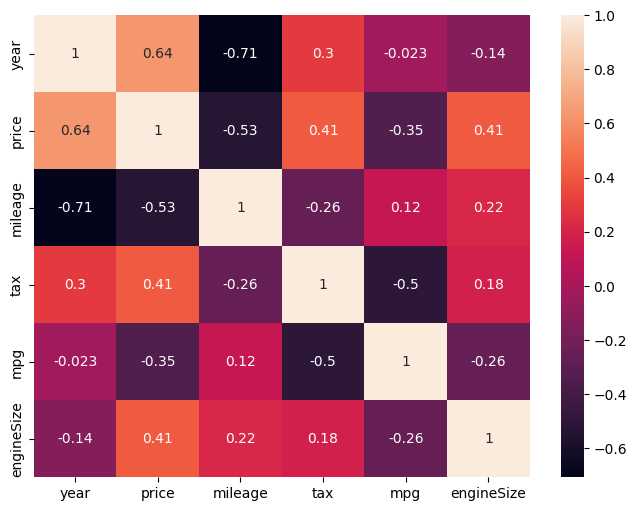

In [89]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

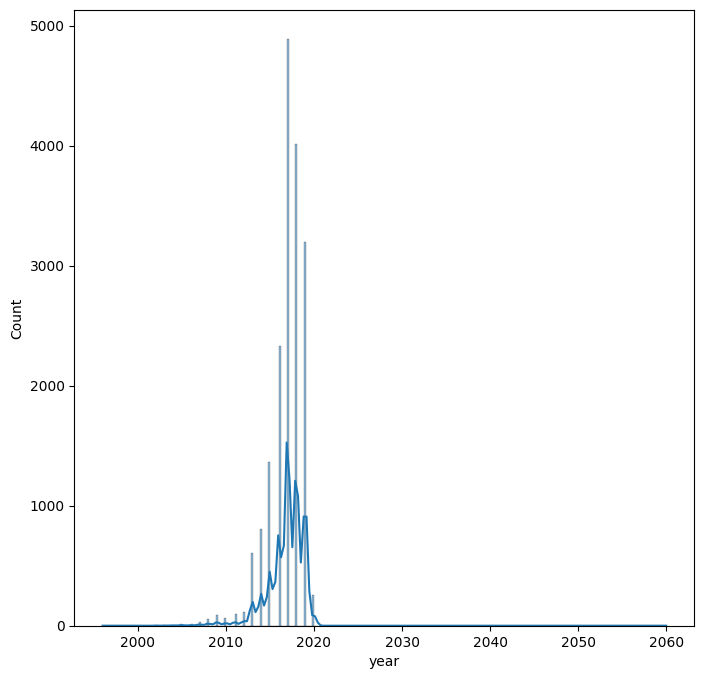

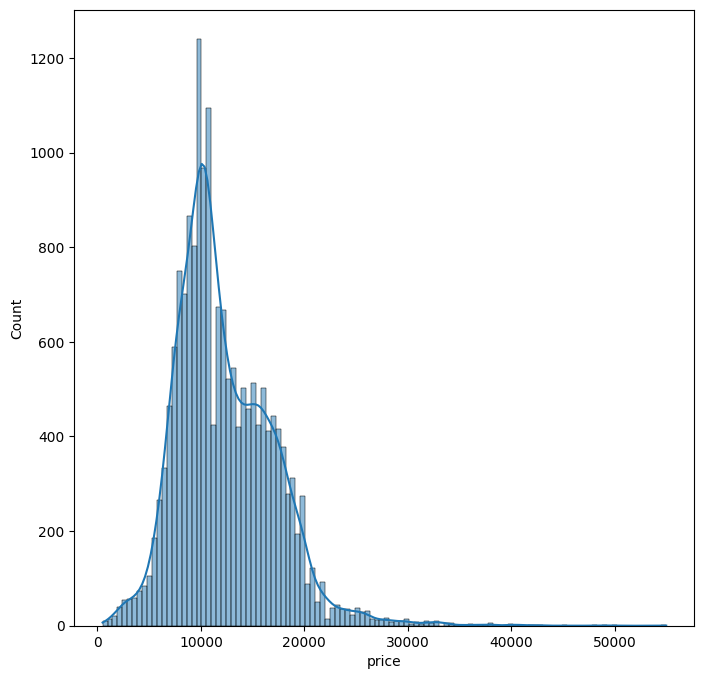

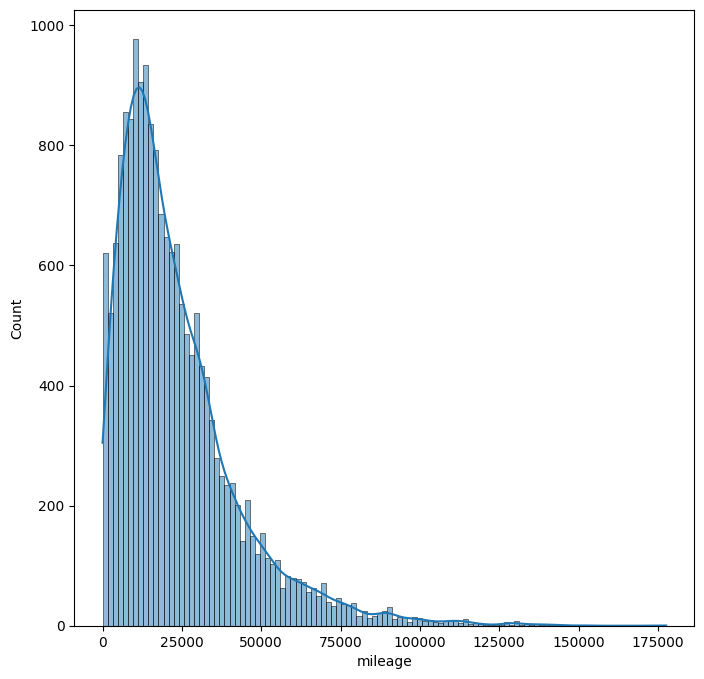

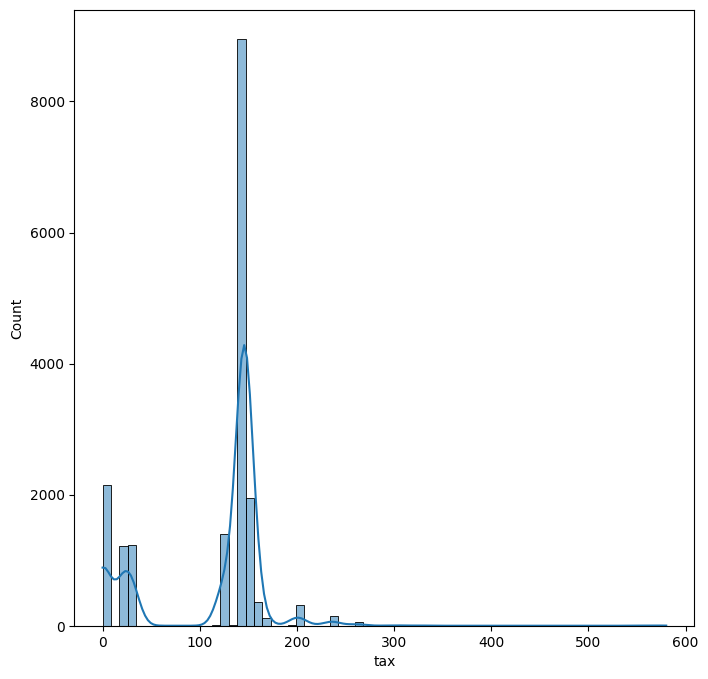

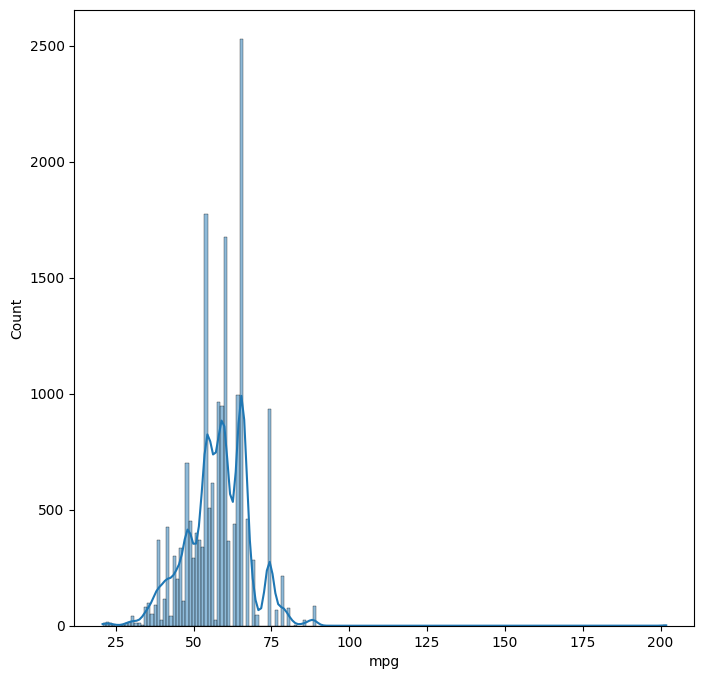

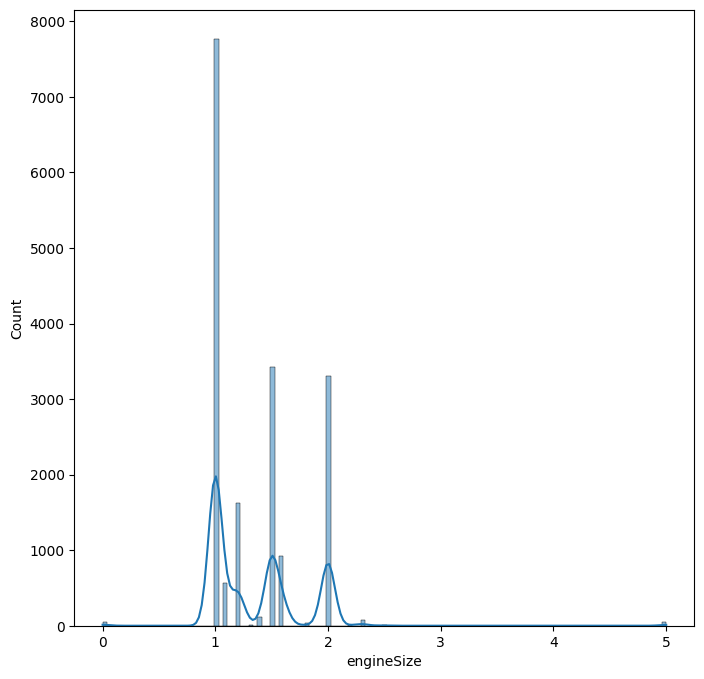

In [90]:
numeric_col=  ['year','price','mileage','tax','mpg','engineSize']
for i in numeric_col:
    plt.figure(figsize=(8,8))
    sns.histplot(df[i],kde=True)
    plt.show()

In [91]:
df['mileage'].value_counts()

mileage
10       40
15000    38
25000    34
10000    32
6000     31
         ..
5046      1
1779      1
10452     1
9725      1
9264      1
Name: count, Length: 13528, dtype: int64

In [92]:
df['engineSize'].value_counts()

engineSize
1.0    7765
1.5    3418
2.0    3311
1.2    1626
1.6     923
1.1     559
1.4     112
2.3      80
0.0      51
5.0      45
1.8      35
2.2      13
2.5      13
1.3      13
3.2       1
1.7       1
Name: count, dtype: int64

# FEATURE ENGINEERING AND SELECTION

In [93]:
df_encode = pd.get_dummies(df, drop_first=True)

In [94]:
df_encode=df_encode.astype(int)

In [95]:
df_encode.head()

,year,price,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,12000,15944,150,57,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2018,14000,9083,150,57,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,2017,13000,12456,150,57,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,2019,17500,10460,145,40,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
4,2019,16500,1482,145,48,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [96]:
from sklearn.preprocessing import StandardScaler

# columns to standardize
cols_to_scale = ['year', 'mileage', 'tax', 'mpg', 'engineSize']

# scaler object
scaler = StandardScaler()

# standardize
df_encode[cols_to_scale] = scaler.fit_transform(df_encode[cols_to_scale])

# view dataframe
df_encode.head()

,year,price,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.065128,12000,-0.380998,0.591358,-0.042122,-0.447984,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0.552866,14000,-0.733359,0.591358,-0.042122,-0.447984,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0.065128,13000,-0.560132,0.591358,-0.042122,-0.447984,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,1.040605,17500,-0.662640,0.510727,-1.721198,-0.447984,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
4,1.040605,16500,-1.123724,0.510727,-0.931045,-0.447984,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [97]:
df_encode.corr()['price']


year                            0.636009
price                           1.000000
mileage                        -0.530659
tax                             0.406857
mpg                            -0.343784
engineSize                      0.495327
model_ C-MAX                   -0.088059
model_ EcoSport                 0.012080
model_ Edge                     0.240388
model_ Escort                  -0.014602
model_ Fiesta                  -0.333103
model_ Focus                    0.111949
model_ Fusion                  -0.061231
model_ Galaxy                   0.133010
model_ Grand C-MAX             -0.034812
model_ Grand Tourneo Connect    0.031421
model_ KA                      -0.158338
model_ Ka+                     -0.131468
model_ Kuga                     0.281025
model_ Mondeo                   0.000959
model_ Mustang                  0.265964
model_ Puma                     0.129318
model_ Ranger                   0.003486
model_ S-MAX                    0.148523
model_ Streetka 

In [98]:
df_encode['price_category'] = pd.qcut(
    df_encode['price'],
    q=5,
    labels=['Very Low','Low','Medium','High','Very High']
)
from scipy.stats import chi2_contingency

alpha = 0.05

categorical_cols = [col for col in df_encode.columns 
                    if 'model_' in col 
                    or 'fuelType_' in col
                    or 'transmission_' in col]

for col in categorical_cols:

    contingency_table = pd.crosstab(
        df_encode[col],
        df_encode['price_category']
    )

    chi2, p, dof, expected = chi2_contingency(contingency_table)

    print(f"\nColumn: {col}")
    print("P-value:", p)

    if p < alpha:
        print("Yes")
    else:
        print("No")


Column: model_ C-MAX
P-value: 3.2092879235907368e-46
Yes

Column: model_ EcoSport
P-value: 3.4554460196657554e-58
Yes

Column: model_ Edge
P-value: 2.675687866481477e-172
Yes

Column: model_ Escort
P-value: 0.4096967492734537
No

Column: model_ Fiesta
P-value: 0.0
Yes

Column: model_ Focus
P-value: 2.768031334718537e-107
Yes

Column: model_ Fusion
P-value: 5.028857706973481e-13
Yes

Column: model_ Galaxy
P-value: 3.42687753724943e-108
Yes

Column: model_ Grand C-MAX
P-value: 2.8359083369564977e-28
Yes

Column: model_ Grand Tourneo Connect
P-value: 7.573801440837695e-08
Yes

Column: model_ KA
P-value: 1.5616883564150953e-133
Yes

Column: model_ Ka+
P-value: 7.580431264352321e-125
Yes

Column: model_ Kuga
P-value: 0.0
Yes

Column: model_ Mondeo
P-value: 0.0018647902134886363
Yes

Column: model_ Mustang
P-value: 2.4631573815107775e-48
Yes

Column: model_ Puma
P-value: 4.2926425887630796e-64
Yes

Column: model_ Ranger
P-value: 0.40121759901252596
No

Column: model_ S-MAX
P-value: 4.176291

In [99]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [100]:
features = [

'year',
'mileage',
'tax',
'mpg',
'engineSize',

'model_ C-MAX',
'model_ Edge',
'model_ Fiesta',
'model_ Focus',
'model_ Fusion',
'model_ Galaxy',
'model_ KA',
'model_ Ka+',
'model_ Kuga',
'model_ Mustang',
'model_ Puma',
'model_ S-MAX',
'model_ Tourneo Custom',

'transmission_Manual',
'transmission_Semi-Auto',

'fuelType_Hybrid',
'fuelType_Petrol'

]

In [101]:
# X and y
X = df_encode[features]
y = df_encode['price']

In [123]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=56
)

In [124]:
model = LinearRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

# OUTPUT

In [125]:
print("Train Score :", model.score(X_train, y_train))
print("Test Score  :", model.score(X_test, y_test))

print("R2 Score    :", r2_score(y_test, y_pred))

print("MAE         :", mean_absolute_error(y_test, y_pred))

print("MSE         :", mean_squared_error(y_test, y_pred))

print("RMSE        :", np.sqrt(mean_squared_error(y_test, y_pred)))
# adjusted r2

n = X_test.shape[0]   # number of rows
p = X_test.shape[1]   # number of features

r2 = r2_score(y_test, y_pred)

adjusted_r2 = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)

print("Adjusted R2 :", adjusted_r2)

Train Score : 0.8383101033963991
Test Score  : 0.8463025772132173
R2 Score    : 0.8463025772132173
MAE         : 1389.7211482984267
MSE         : 3664712.3077736422
RMSE        : 1914.343832171651
Adjusted R2 : 0.8453556874620806


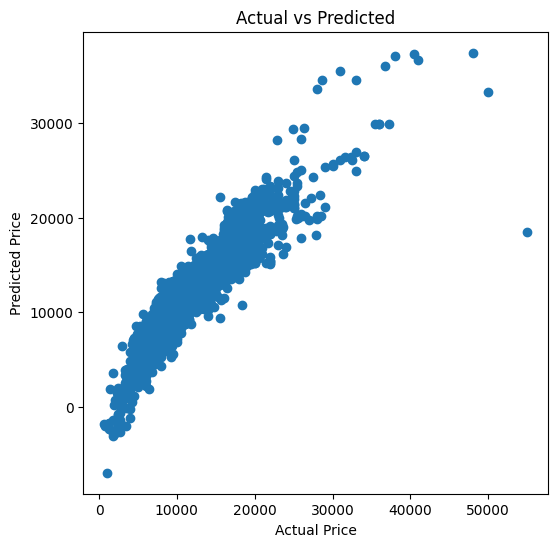

In [126]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

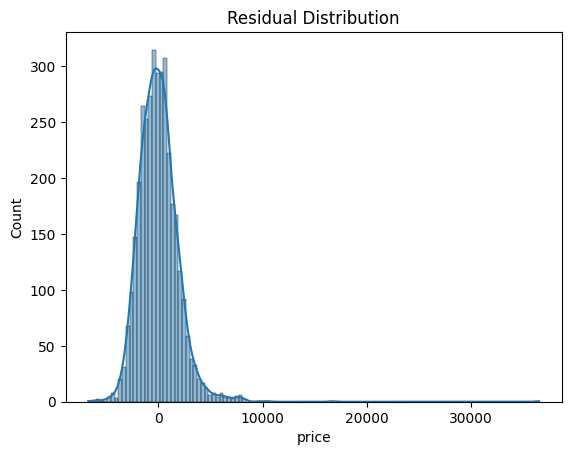

In [127]:
residuals = y_test - y_pred

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()